In [1]:
"""
学習済みモデルVGG16を利用して画像の判定モデルを構築します。
"""

'\n学習済みモデルVGG16を利用して画像の判定モデルを構築します。\n転移学習により、少量のデータや学習プロセスで予測モデルを効果的に構築できます。\n'

In [2]:
"""
1. VGG16の取得

まず、KerasのライブラリからVGG16をインポートし、変数に代入します。
引数にweights='imagenet'と指定することで、
ImageNetデータセットで事前学習されたパラメータ（重みと閾値）を持つ予測モデルを読み込めます。
"""
from tensorflow.keras.applications.vgg16 import VGG16
model = VGG16(weights='imagenet')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 33s 0us/step


In [3]:
"""
2. VGG16の可視化
"""
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

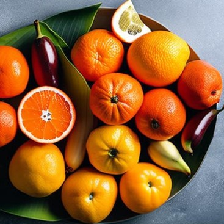

In [4]:
"""
3. サンプルデータの取得

予測をしたい画像データを取得します。
https://drive.google.com/file/d/1gRKwwTp_augOaYOzN6TYn7qufMGyG-Vj/view
次に、load_img関数で画像を取り込みます。

target_sizeパラメータで、取り込み時の画像のサイズを指定できます。
なお、VGG16の可視化によって、
インプットデータの構造が「任意のサンプル数×224×224×3」であることを確認できました。
VGG16へ画像データを投入するための前処理に手間がかからないよう、
target_sizeとして縦224ピクセル×横224ピクセルを指定します。
"""
from tensorflow.keras.preprocessing.image import load_img
unknown_img = load_img('/content/unknown_vgg.jpg', target_size=(224, 224))
unknown_img

In [5]:
"""
サンプルデータの前処理

続いて、画像データを予測モデルに入力する前に、適切な形式へ変換します。
まずは、img_to_array関数で画像をarray形式に変更します。
"""
from tensorflow.keras.preprocessing.image import img_to_array
unknown_array = img_to_array(unknown_img)
unknown_array.shape

(224, 224, 3)

In [6]:
"""
VGG16の可視化で確認した通り、インプットデータの構造は「任意のサンプル数×224×224×3」です。
reshape関数で同じデータ構造に変換します。
"""
unknown_array = unknown_array.reshape((1, 224, 224, 3))
unknown_array.shape

(1, 224, 224, 3)

In [7]:
"""
4. サンプルデータの前処理

VGG16のpreprocess_input関数を利用して、前処理を実施します。
この関数は、VGG16用に前処理が実行できる関数です。
"""
from tensorflow.keras.applications.vgg16 import preprocess_input
unknown_array = preprocess_input(unknown_array)

In [8]:
#次に、VGG16を使って画像データの予測をします。
result = model.predict(unknown_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [9]:
"""
次に、resultを表示します。

予測結果として、1000種類のカテゴリそれぞれに属する確率が表示されています。
ImageNetデータセットで事前学習されたVGG16は、
1000カテゴリそれぞれに属する確率を出力するように学習されているためです。

なお、1000カテゴリの詳細については、以下を参照してください。
https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/
"""
result

array([[1.11725509e-08, 4.89423371e-07, 3.93451449e-09, 8.92244167e-10,
        1.65926051e-10, 8.15076506e-10, 7.50456974e-10, 3.83191043e-08,
        3.24300885e-07, 2.16291193e-10, 1.27581137e-08, 2.96107654e-08,
        9.11737974e-09, 2.54532351e-09, 7.84278065e-09, 8.52190055e-07,
        3.27272346e-07, 2.91347391e-08, 9.65541389e-08, 1.64874991e-09,
        3.73937459e-09, 5.76805104e-10, 3.87632176e-10, 5.61215741e-10,
        6.26211583e-10, 5.91522165e-09, 1.81357307e-09, 2.73654166e-09,
        4.16828883e-09, 1.01353246e-08, 1.54444391e-09, 3.66637920e-08,
        1.60665703e-09, 2.15357687e-09, 6.11598416e-09, 2.35707653e-09,
        2.15745075e-08, 2.24178560e-08, 1.97570446e-10, 9.47189882e-09,
        7.22527327e-09, 1.47335610e-09, 5.07120623e-10, 1.77938098e-09,
        1.58129773e-10, 2.26414709e-09, 1.84121678e-08, 3.39396977e-09,
        1.72227413e-10, 1.42641143e-09, 1.43496359e-09, 4.02675093e-09,
        1.30943567e-09, 7.08680392e-10, 8.61743343e-10, 9.638562

In [10]:
"""
decode_predictions関数を利用すると、
可能性の高い上位5つのカテゴリと、そのカテゴリに属する確率が表示されます。
"""
from tensorflow.keras.applications.vgg16 import decode_predictions
decode_predictions(result)

#以上が、VGG16を利用した画像判定の流れとなります。

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[[('n07747607', 'orange', np.float32(0.84372026)),
  ('n07753592', 'banana', np.float32(0.065719865)),
  ('n07749582', 'lemon', np.float32(0.044244602)),
  ('n07753275', 'pineapple', np.float32(0.028791554)),
  ('n07716906', 'spaghetti_squash', np.float32(0.0031751017))]]